In [26]:
# Load the pandas library for working with tables (DataFrame)
import pandas as pd

# Regular expression library; used for text cleaning (e.g., removing URLs and punctuation)
import re

# NumPy: package for numerical computations and multidimensional arrays
import numpy as np

# Function for randomly splitting data into training, validation, and test sets
from sklearn.model_selection import train_test_split

# Keras Tokenizer: converts words into integer indices and builds a vocabulary from the training set
from tensorflow.keras.preprocessing.text import Tokenizer

# pad_sequences: standardizes all text sequences to the specified MAXLEN by padding or truncating words
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Sequential: a simple model in which layers are added one after another
from tensorflow.keras.models import Sequential

# EarlyStopping and ReduceLROnPlateau are callbacks that:
# - EarlyStopping: stops training when val_loss does not improve after the specified patience
# - ReduceLROnPlateau: reduces the learning rate when val_loss stagnates, allowing finer model adjustment
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau


# Import key CNN layers for text processing:
# - Embedding: converts word indices into dense embedded vectors (embeddings)
# - Conv1D: applies 1D convolution to detect local n-gram patterns in text
# - GlobalMaxPooling1D: compresses the temporal dimension by taking the maximum activation of each filter
# - Dense: fully connected layer for learning abstract combinations of features
# - Dropout: randomly disables neurons to prevent overfitting
# - SpatialDropout1D: disables entire embedding channels, encouraging model robustness
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout, SpatialDropout1D

# Adam optimizer: an adaptive optimizer that combines the advantages of AdaGrad and RMSProp,
# automatically adjusting the learning rate for each model parameter
from tensorflow.keras.optimizers import Adam

# Model evaluation tools:
from sklearn.metrics import (
    # Since we work with binary classification, FAKE (0) vs. REAL (1),
    # confusion_matrix returns a 2×2 matrix of the form:
    #   [[TN, FP],
    #    [FN, TP]]
    #
    # Where:
    #   TN (True Negative)  - FAKE (0) cases correctly classified as FAKE
    #   FP (False Positive) - FAKE (0) cases incorrectly classified as REAL
    #   FN (False Negative) - REAL (1) cases incorrectly classified as FAKE
    #   TP (True Positive)  - REAL (1) cases correctly classified as REAL
    confusion_matrix,
    # ConfusionMatrixDisplay: makes the confusion matrix easier to visualize
    ConfusionMatrixDisplay
)

# matplotlib.pyplot: core Python library for plotting graphs and visualizations
import matplotlib.pyplot as plt


In [3]:
# Load the CSV file containing news data
df = pd.read_csv("fake_or_real_news.csv")
print(df.head())
# If the automatic CSV index ("Unnamed: 0") is present, remove it because it is not needed
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

# Remove rows with missing values in the title, text, or label
# Without complete title, text, and label information, the model cannot be trained correctly
df = df.dropna(subset=["title", "text", "label"])

# Combine the title and text into a new "full_text" column
# .str.strip() removes extra whitespace at the beginning and end of each string value
df["full_text"] = df["title"].str.strip() + " " + df["text"].str.strip()

# Map the text labels "FAKE" and "REAL" to numeric values (0 and 1)
# This gives the "y" column, which the model uses as the target variable
df["y"] = df["label"].map({"FAKE": 0, "REAL": 1})


   Unnamed: 0                                              title  \
0        8476                       You Can Smell Hillary’s Fear   
1       10294  Watch The Exact Moment Paul Ryan Committed Pol...   
2        3608        Kerry to go to Paris in gesture of sympathy   
3       10142  Bernie supporters on Twitter erupt in anger ag...   
4         875   The Battle of New York: Why This Primary Matters   

                                                text label  
0  Daniel Greenfield, a Shillman Journalism Fello...  FAKE  
1  Google Pinterest Digg Linkedin Reddit Stumbleu...  FAKE  
2  U.S. Secretary of State John F. Kerry said Mon...  REAL  
3  — Kaydee King (@KaydeeKing) November 9, 2016 T...  FAKE  
4  It's primary day in New York and front-runners...  REAL  


In [4]:
# Function that cleans string s; we aim to simplify the model input so that it is not burdened
# with potentially irrelevant details in the text
def normalize_and_clean(s):
    # Replace different variants of quotation marks and dashes with standard ASCII characters
    s = s.replace("’", "'").replace("“", '"').replace("”", '"').replace("—", "-")
    # Convert to lowercase for uniformity
    s = s.lower()
    # Remove URLs (http, https, www)
    s = re.sub(r"http\S+|www\S+|https\S+", "", s)
    # Remove HTML tags
    s = re.sub(r"<.*?>", "", s)
    # Convert all characters except word characters and whitespace into spaces
    s = re.sub(r"[^\w\s]", " ", s)
    # Replace multiple spaces with one and strip spaces at the edges
    s = re.sub(r"\s+", " ", s).strip()
    return s

# Apply the original cleaning function to the combined text
df["clean_text"] = df["full_text"].apply(normalize_and_clean)

# Split the data into a training+validation set (90%) and a test set (10%)
# Stratification by the 'y' column preserves the class ratio in both parts
df_train_val, df_test = train_test_split(
    df,
    test_size=0.10,
    random_state=42,
    stratify=df["y"]
)

# Additional split of the training+validation set:
# 89% training, 11% validation (which overall gives approximately 80% training, 10% validation, 10% test)
df_train, df_val = train_test_split(
    df_train_val,
    test_size=0.11,
    random_state=42,
    stratify=df_train_val["y"]
)


In [5]:
# Define the maximum vocabulary size: take the most frequent MAX_VOCAB_SIZE words
MAX_VOCAB_SIZE = 120000

# Initialize a Tokenizer that:
# - builds a word-index map based on the training text
# - maps all words outside this limit to the "<UNK>" token - "unknown / out-of-vocabulary token"
#   instead of raising a potential error, assigns unknown words a unique index (usually 1)
tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE, oov_token="<UNK>")

# 'fit_on_texts' scans all sentences in the training set
# and counts word occurrences, building a frequency ranking
tokenizer.fit_on_texts(df_train["clean_text"])

# Convert each cleaned text into a sequence of integer indices
# Words are mapped to vocabulary positions or to <UNK> if they are not among the first 120,000
X_train_seq = tokenizer.texts_to_sequences(df_train["clean_text"])
X_val_seq   = tokenizer.texts_to_sequences(df_val["clean_text"])
X_test_seq  = tokenizer.texts_to_sequences(df_test["clean_text"])


In [6]:
# Define a fixed input sequence length of MAXLEN tokens
# Longer sequences are truncated, and shorter ones are padded with zeros at the end
MAXLEN = 150

# Pad or truncate so that each sequence has length MAXLEN
# padding="post" adds 0 at the end of the sequence, and truncating="post" truncates at the end
# After this, for example, X_train_pad becomes a matrix of shape (number_of_training_examples, MAXLEN),
# where each row contains exactly 150 integers (word indices or 0 for padding).
X_train_pad = pad_sequences(X_train_seq, maxlen=MAXLEN, padding="post", truncating="post")
X_val_pad   = pad_sequences(X_val_seq,   maxlen=MAXLEN, padding="post", truncating="post")
X_test_pad  = pad_sequences(X_test_seq,  maxlen=MAXLEN, padding="post", truncating="post")

# Extract target variables (0=FAKE, 1=REAL) from the DataFrame and convert them into NumPy arrays
# y_train, y_val, and y_test have lengths equal to the number of rows in X_train_pad, X_val_pad, and X_test_pad
y_train = df_train["y"].values
y_val   = df_val["y"].values
y_test  = df_test["y"].values


In [7]:
def classify_news(model, sentence):
    # 1) Clean and normalize the input text
    cleaned = normalize_and_clean(sentence)
    
    # 2) Convert the text into a sequence of integers (word indices):
    #    - tokenizer.texts_to_sequences expects a list of strings and returns a list of index lists,
    #      where each sublist corresponds to one sentence.
    #    - We put `cleaned` into the list `[cleaned]` to obtain a batch containing one text.
    #    - The result is something like [[12, 45, 78, ...]] - a list with one inner list.
    #    - [0] takes that only inner list, i.e., the index sequence itself.
    seq = tokenizer.texts_to_sequences([cleaned])[0]
    
    # 3) Pad or truncate the sequence to exactly MAXLEN tokens
    pad = pad_sequences([seq], maxlen=MAXLEN, padding="post", truncating="post")[0]
    
    # 4) Predict the probability using the model
    #    - pad.reshape(1, -1): reshapes a 1D array of length MAXLEN into a 2D array of shape (1, MAXLEN),
    #      i.e., a batch of one example so that it matches the model input.
    #    - model.predict(..., verbose=0): passes the data through the network and returns an array of shape (batch_size, 1);
    #      verbose=0 disables the progress-bar output.
    #    - [0][0]: extracts the only element from the result of shape (1,1), i.e., the scalar probability.
    prob = model.predict(pad.reshape(1, -1), verbose=0)[0][0]
    
    # 5) Determine the label based on the threshold 0.5
    label = "REAL" if prob > 0.5 else "FAKE"
    
    # 6) Print the result
    print(f"Probability of REAL: {prob:.4f}")
    print(f"Predicted label:     {label}")


In [10]:
def plot_confusion(model, X, y, labels=("FAKE", "REAL"), title="Confusion Matrix"):
    # 1) Obtain the predicted probability for each sample
    #    model.predict(X) returns a NumPy array of shape (n_samples, 1) with P(REAL)
    y_pred_prob = model.predict(X)
    
    # 2) Convert probabilities into discrete labels (0 or 1)
    #    - (y_pred_prob > 0.5) gives a Boolean array: True where P(REAL)>0.5
    #    - .astype(int) converts True/False to 1/0
    #    - .flatten() flattens the array into a 1D array of length n_samples
    y_pred = (y_pred_prob > 0.5).astype(int).flatten()
    
    # 3) Compute the confusion matrix
    #    cm = [[TN, FP],
    #          [FN, TP]]
    #    where:
    #      TN = correctly recognized FAKE (0)
    #      FP = FAKE incorrectly labeled as REAL
    #      FN = REAL incorrectly labeled as FAKE
    #      TP = correctly recognized REAL (1)
    cm = confusion_matrix(y, y_pred)
    
    # 4) Prepare the display object for the matrix with class labels
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    
    # 5) Create the figure and axes for plotting
    #    figsize=(6,5) sets the dimensions in inches
    fig, ax = plt.subplots(figsize=(6, 5))
    
    # 6) Plot the matrix on the defined axis
    disp.plot(ax=ax, cmap="Blues")
    
    # 7) Set the plot title
    ax.set_title(title)
    
    # 8) Adjust the layout so nothing is clipped
    plt.tight_layout()
    
    # 9) Show the plot
    plt.show()

In [49]:
def plotMetrics(history):
    acc      = history.history['accuracy']
    val_acc  = history.history['val_accuracy']
    loss     = history.history['loss']
    val_loss = history.history['val_loss']
    epochs   = range(1, len(acc) + 1)
    
    plt.figure(figsize=(10, 6))
    
    plt.plot(epochs, acc,     'bo-', label='Training accuracy')
    plt.plot(epochs, val_acc, 'ro-', label='Validation accuracy')
    
    # Plot training and validation loss
    plt.plot(epochs, loss,     'b--', label='Training loss')
    plt.plot(epochs, val_loss, 'r--', label='Validation loss')
    
    # Title and axis labels
    plt.title('Accuracy and Loss over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Value')
    
    # Legend and grid
    plt.legend()
    plt.grid(True)
    
    # Adjust the layout and show the plot
    plt.tight_layout()
    plt.show()

In [18]:
# Example 1: REAL news about Mars rock sampling
# Detailed report on the Perseverance mission, including the SHERLOC, PIXL, SuperCam, and MOXIE instruments,
# the landing date in Jezero Crater, sample collection, and future plans for returning rocks to Earth.
nasa_real = """
NASA’s Perseverance Rover Successfully Collects First Mars Rock Sample

The Perseverance rover, part of NASA’s Mars 2020 mission, represents a historic milestone in planetary exploration. Launched on July 30, 2020, from Cape Canaveral, Florida, Perseverance landed in Jezero Crater on February 18, 2021. Jezero Crater was chosen because billions of years ago it contained a lake fed by a river delta, making it a prime location to search for signs of ancient microbial life. Over the course of 687 Earth days (one Martian year), the rover traversed rocky terrain, using its advanced suite of scientific instruments to conduct in-situ analyses. These instruments include SHERLOC (Scanning Habitable Environments with Raman & Luminescence for Organics and Chemicals), which can detect organic molecules by using spectroscopic techniques; PIXL (Planetary Instrument for X-ray Lithochemistry), which is capable of performing fine-scale elemental analysis; and SuperCam, which can image, measure mineralogy, and detect organic compounds from a distance with its laser-induced breakdown spectroscopy (LIBS) and Raman spectroscopy. An onboard weather station, MEDA (Mars Environmental Dynamics Analyzer), recorded atmospheric pressure, wind speed, temperature, and dust levels, contributing to a better understanding of Martian meteorology and dust behavior.

On Sol 549 (the 549th Martian day since landing), Perseverance used its drill to collect a sample from a flat, smooth rock outcrop nicknamed “Rochette.” The rover’s Coring Bit Assembly extracted a cylindrical core approximately 2.4 centimeters in diameter and 6.8 centimeters long. The rock sample, encased in a sealed titanium tube, contained sedimentary deposits rich in clay minerals—a potential biosignature reservoir. After extraction, the sample tube was stowed inside the rover’s cache system. Future missions in NASA’s Mars Sample Return campaign will rendezvous with Perseverance to retrieve these sealed samples and eventually bring them back to Earth for comprehensive laboratory analysis. These returned samples could reveal detailed geochemical and mineralogical signatures, offering unprecedented insight into ancient Martian environments, including whether microbial life ever existed there.

Perseverance is powered by an MMRTG (Multi-Mission Radioisotope Thermoelectric Generator), which converts heat from decaying plutonium-238 into electricity, enabling the rover to operate during long winter nights and dust storms. The rover’s wheels are made of aluminum and measure 52.5 centimeters (20.7 inches) in diameter, designed to navigate sharp rocks and soft dunes. Each wheel has cleats, called grousers, to provide traction on loose soil. However, in late 2022 engineers noticed faster-than-expected wear on the wheel treads, prompting a comprehensive analysis of Martian terrain abrasion rates. To compensate, Perseverance traveled more conservatively and used alternate routes to avoid especially rugged surfaces.

In addition to geology and astrobiology objectives, Perseverance carries MOXIE (Mars Oxygen In-Situ Resource Utilization Experiment), a technology demonstration that produces oxygen from Martian atmospheric CO₂. MOXIE uses solid oxide electrolysis to split CO₂ molecules into oxygen and carbon monoxide. On several occasions, MOXIE successfully generated about 6 grams of oxygen—enough for a small “breath” for an astronaut—and demonstrated that future human missions could use Martian resources to produce rocket propellant, breathable oxygen, and life support consumables. The success of MOXIE paves the way for larger, scaled-up in-situ resource utilization (ISRU) systems, which will be essential for sustained human presence on Mars.

Communication with Earth occurs via NASA’s Deep Space Network (DSN), which relays commands from mission control in Pasadena, California, to the rover and transmits high-resolution images and scientific data back. Perseverance is equipped with a wide-angle front Hazcam, rear Hazcam, Navcam, and Mastcam-Z (a zoom-capable camera system), which capture geological context and panoramic views. Ingenuity, a small helicopter deployed from Perseverance, demonstrated powered flight in Mars’ thin atmosphere—another historic first. Ingenuity’s flights sought to prove that aerial exploration in the Martian atmosphere is feasible, and its success has informed designs for future rotorcraft missions.

Mission scientists have logged over 10 terabytes of data, including more than 250,000 high-resolution images, rock and soil chemistry readings, weather reports, and audio recordings of Martian winds. These datasets are publicly archived in NASA’s Planetary Data System (PDS), enabling researchers worldwide to conduct independent analyses. Among the most intriguing findings so far are the detection of organic compounds in the Jezero delta, the identification of silica-rich deposits formed in ancient hydrothermal systems, and the characterization of seasonal methane fluctuations in the Martian atmosphere—all of which have significant implications for Mars’ past habitability.

Perseverance will continue exploring, drilling, and caching samples for as long as its nuclear power source remains sufficient and its hardware remains healthy. Its achievements represent a technological marvel and a major step toward answering one of humanity’s most profound questions: Did life ever exist on Mars? By returning pristine samples to Earth laboratories, we will be able to apply cutting-edge analytical tools—mass spectrometry, X-ray diffraction, electron microscopy—to detect even the faintest biosignatures. Future NASA, ESA, and international missions will build on Perseverance’s legacy, bringing us closer than ever to unraveling Mars’ mysteries.
"""

# Example 2: FAKE news about experimental energy production from dark matter
# Fictional report on the “Dark Harvest Project”, where dark matter produces kilowatt-scale electrical power
darkMatter_fake = """
Breakthrough Discovery: Dark Matter Transforms into Clean Energy Overnight

In an announcement that has shaken the foundations of modern physics and energy policy, researchers at the (fictitious) Quantum Future Institute (QFI) claim to have recorded the first laboratory observation of dark matter “decay” into usable electricity. According to Dr. Helena Vortex, lead author of the paper published earlier this week in the peer-reviewed journal Astrophysical Innovations, an experimental chamber cooled to 0.1 Kelvin revealed a series of gamma-ray bursts accompanied by a novel energy signature that matched theoretical predictions for dark-matter annihilation. “We have been hunting for any sign that dark matter could couple to the Standard Model in a way that yields observable photons,” said Dr. Vortex. “What we observed was a series of high-energy pulses that directly converted into a stable 0.9 MeV electron beam, which we then routed through a superconducting flux array to harvest continuous electrical current. In essence, dark matter is literally powering our laboratory.”

The QFI team’s “Dark Harvest Project” involved isolating a kilogram of a specially synthesized xenon‐127 isotope that, when subjected to a precise magnetic confinement field, became a target for ambient dark‐matter particles streaming through the lab at nearly 0.3 c. Over several months of continuous monitoring, the detectors—algorithms built on a custom variant of quantum‐dot photomultiplier tubes—registered a recurring pattern of annihilation events at exactly 14.1 kHz. Each event produced approximately 1 joule of net electrical output, and with a reaction rate of 10^6 events per second, the team claims they have already sustained a kilowatt‐level power output for a total of 144 hours. “If verified,” Dr. Vortex added, “this could revolutionize energy worldwide: an inexhaustible, zero‐emissions power source harnessing the very fabric of the cosmos.”

Despite the apparent success, many in the scientific community remain skeptical. Dr. Rafael Orlov, a dark‐matter theorist at the (real) Nova Tech University, published a scathing commentary on QFI’s methodology. “There are multiple confounding factors, including cosmic‐ray muon contamination, residual radioisotope background, and calibration drifts in the photon‐detection subsystem,” Dr. Orlov wrote. “Until independent groups can replicate these results under entirely different shielding and detector configurations, it remains premature to proclaim that we have harnessed dark matter.” Nonetheless, the QFI experiment has already attracted the attention of several national governments. A leaked memo from the Global Energy Coalition (GEC) indicates that China, Germany, and Brazil have each pledged USD 500 million to establish “Dark Harvest Test Facilities” capable of producing 100 kW of continuous DC output from dark‐matter interactions.

Meanwhile, critics in environmental and policy circles are issuing urgent cautions. The Sustainable Futures Alliance (SFA) released a statement urging a “measured approach” to funding QFI’s expansion. “There are grave geopolitical risks in deploying unproven quantum‐harvest reactors,” warns Dr. Amara Ren, Senior Policy Analyst at the SFA. “If even a small fraction of the experimental chamber’s containment fails, we could see gamma fluxes equivalent to multiple roentgens per hour—enough to create localized radiation hazards. Additionally, the procurement of xenon‐127 at scale would be extremely expensive, and unsustainable for most developing nations.” Dr. Ren also points out that the theoretical framework behind QFI’s claim conflicts with the widely accepted Lambda Cold Dark Matter (ΛCDM) model. “The Lambda‐CDM paradigm predicts dark‐matter self‐annihilation cross‐sections that are orders of magnitude smaller than those needed to generate this much power.”

In a separate but related development, a frontier‐tech startup named NovaGen has announced a partnership with QFI to develop a “DarkCore Reactor” for commercial deployment within five years. NovaGen’s CEO, Marcus Eldridge, claims that their preliminary designs could retrofit existing nuclear plants to use dark matter instead of uranium as fuel. “Our engineers believe we can achieve net‐positive yield with only 0.5 grams of xenon per day,” said Eldridge. He further asserted that “state‐of‐the‐art superconducting containment vessels” will reduce radiation leakage by a factor of 10⁵ compared to conventional reactors. The CEO’s optimism has not dissuaded regional regulators, however. The United States Nuclear Regulatory Commission (NRC) issued a public warning last Friday that “any technology claiming to directly convert dark‐matter particles into electricity must conform to existing federal safety requirements for extremal radiation.” The NRC has scheduled a series of public hearings to review QFI’s and NovaGen’s protocols for shielding, radiation monitoring, and emergency shutdown procedures.

On social media, the reaction has been equally polarized. Hashtags like #DarkHarvest and #QuantumPowerTrend have gone viral, with tweets stating everything from “Finally, an end to fossil fuels!” to “Dark matter scams are the new crypto!” Even Elon Turing, a well‐known tech billionaire (fictional), tweeted: “If QFI’s dark‐matter reactor is real, I’ll build the first orbital power satellite converting space‐based dark matter flux into grid electricity.” Shortly afterward, he posted a follow‐up tweet he later deleted: “Note to self: check if dark matter even exists.” Despite the jokes, venture capital is already flowing: TechVenture Partners announced a USD 200 million “Dark Energy Fund” to finance startups that leverage dark‐matter research. Leading economists caution that if QFI’s claims are disproven, a massive “dark-matter bubble” could cause severe market corrections, reminiscent of the dot-com bust.

For now, the scientific community remains on tenterhooks. An international consortium of astrophysicists and particle physicists (including Nobel laureates from the European Organization for Nuclear Research) plans to replicate QFI’s results using a 10-liter liquid-argon time projection chamber (LArTPC). The so-called “Aurora Project” will deploy its detectors 1 kilometer underground at the Arctic Neutrino Observatory, aiming to rule out cosmic‐ray muon interference entirely. Data collection is expected to begin in late 2025. Meanwhile, the QFI team continues to operate its test reactor, powering the entire institute’s campus lighting solely from “dark current.” According to their website, they have now recorded 1 000 hours of uninterrupted operation—though they admit that gamma flux fluctuations still require manual recalibration every 12 hours. Whether this is the energy revolution of the 21st century or merely another grand scientific hoax remains to be seen. What’s certain is that the world will be watching.
"""

# Example 3: REAL news about increasing investment in renewable energy sources
# IREA report on global capital flows into solar, wind, and other clean technologies,
# EU, U.S., and Chinese policies, and key projects and regulatory measures.
energy_real = """
Global Renewable Energy Investments Surge as Nations Commit to Net-Zero Targets

In a landmark series of policy announcements this past week, governments around the world have redoubled their commitments to achieving net-zero carbon emissions by mid-century, leading to a dramatic surge in investments in renewable energy projects. According to a report released by the International Renewable Energy Agency (IREA), global capital flows into solar, wind, and other clean-energy technologies reached a record USD 450 billion in the first quarter of this year—25 percent higher than the same period last year. The IREA’s quarterly “Global Clean Energy Finance Tracker” attributes much of this growth to newly enacted legislation in the European Union, China, and the United States, each of which has pledged to accelerate the transition away from fossil fuels.

In Brussels, the European Commission confirmed plans to increase the EU’s 2030 renewable energy target from 32 percent to 40 percent of total energy consumption. This adjustment is part of the “Green Future Pact” unveiled by President Ursula von der Leyen, which aims to reduce greenhouse gas emissions by at least 55 percent below 1990 levels by 2035. Member states have also agreed to allocate an additional EUR 50 billion of the existing Recovery and Resilience Facility to support the deployment of large-scale offshore wind farms in the North Sea and Mediterranean, as well as distributed rooftop solar systems in urban areas. According to IREA, these new commitments will directly stimulate approximately EUR 120 billion of investment in clean power generation and grid modernization over the next five years.

Meanwhile, in Beijing, China’s National Development and Reform Commission announced that the country will target 60 percent of its electricity generation from non-fossil sources by 2030—up from 43 percent in 2022. To achieve this accelerated rollout, China will increase its feed-in-tariff subsidies for photovoltaic (PV) installations and set aside an additional CNY 200 billion in low-interest loans for wind-turbine manufacturers. State-owned enterprises have also been instructed to cap coal power utilization at 2022 levels and to invest in battery-storage integration with new solar farms. Observers note that China’s domestic clean-energy industry, which already produces roughly half of the world’s solar panels and a third of global wind turbines, will benefit from this policy in two ways: stronger home-market demand and improved access to preferential financing.

Across the Pacific, the U.S. Senate passed a “Clean Power Infrastructure Act” (CPIA) with bipartisan support, authorizing USD 150 billion in grants and tax credits for renewable power projects, energy storage, and grid resilience improvements. Of this amount, USD 40 billion will go toward incentives for residential and commercial rooftop solar installations, up from USD 15 billion under earlier proposals. An additional USD 30 billion has been earmarked for the expansion of high-voltage transmission lines to connect wind farms in the Great Plains to population centers along the East Coast. Energy Secretary Maya Patel stated that these measures would help reduce U.S. greenhouse gas emissions by 40 percent below 2005 levels by 2030, putting the country on track to meet its Paris Agreement commitments. In conjunction with the CPIA, the Environmental Protection Agency (EPA) finalized stricter emissions standards for coal-fired power plants, requiring an average 15 percent reduction in carbon emissions by 2028 compared to current levels.

Investors have responded enthusiastically. Clean-energy venture capital deals in Silicon Valley and elsewhere reached USD 10 billion in Q1 2025, according to data from TechFunds Analytics. Major utility companies have also announced multi-billion-dollar acquisitions of battery-storage firms and solicitations for offshore wind power purchase agreements. NextEra Energy, one of the largest utilities in the United States, confirmed a USD 5 billion plan to build a combined 2 gigawatts (GW) of solar-plus-storage projects across Texas and California. Similarly, Ørsted, a Danish multinational energy company, finalized a EUR 3 billion deal to acquire a 1.2 GW offshore wind farm off the coast of New Jersey, marking its first major U.S. investment.

Despite these optimistic developments, some analysts caution that supply-chain constraints and permitting delays could slow down project timelines. The Biden Administration’s ambitious infrastructure objectives hinge on streamlining the approval process for interstate transmission lines—a process that currently can take up to a decade under existing regulations. In Europe, environmental groups have protested certain wind-farm proposals, demanding more rigorous assessments of impacts on marine wildlife and fisheries. Meanwhile, the World Bank has warned that developing countries may face financing challenges unless wealthy nations fulfill their pledges to deliver USD 100 billion per year in climate aid.

Nevertheless, the global trajectory seems clear: governments and corporations alike are increasingly viewing renewable energy not as an optional alternative, but as the cornerstone of economic growth and energy security. As land-based solar installations, offshore wind farms, and large battery storage facilities proliferate, the energy sector is entering a transformation on the scale of the Industrial Revolution. Policy experts emphasize that collaboration between public and private sectors will be critical to addressing challenges related to grid integration, critical mineral supply for battery production, and workforce training for clean-energy technicians. With these reforms now firmly in motion, many believe that the next decade could mark the tipping point at which renewable power eclipses fossil fuels as the dominant source of global electricity generation.
"""

# Example 4: FAKE April Fools' joke from the Index.hr portal
# Humorous news story about Morgan Freeman appearing in a series about Franjo Tuđman, published on April 1,
# appropriately classified as fake news because of its sensationalist and unrealistic claims.
index_fake = """
“Netflix Makes a Series About Franjo Tuđman. He’s Played by Morgan Freeman”

“ZAGREB, April 1 – Netflix announced that at the end of the year it will release a miniseries called Stranger which deals with the life of Franjo Tuđman. Tuđman will be played by Morgan Freeman. The series has a somewhat odd title, which comes from the surname of Croatia’s first president – Tuđman – which Netflix translated as Stranac, meaning “stranger” or “foreign man.”

‘We wanted to make an inclusive series about a person who has lived under multiple systems. From Partisans and Communists, to a prisoner, to HDZ, and then the first President of Croatia. A fascinating life,’ said Marc Robson, Netflix’s Executive Director for Europe.

‘Tuđman is interesting precisely because he was first in prison and then in HDZ. Usually it’s the other way around,’ he added.

Šeks Will Play Himself  
He also responded to accusations of promoting a so-called woke agenda and inventing things that never happened in order to appeal to a broader audience and promote inclusivity. ‘Yes, I must admit that this time the accusations make sense. In the series, several HDZ members are honest, which does not correspond to historical truth. We did that for the plot,’ he added.

The series is expected to gather significant acting names. The only person who will play himself will be Vladimir Šeks. At the press conference where Šeks also participated, a minor incident occurred. Since English letters do not have diacritics, “Šeks” was renamed “Seks,” which Netflix’s algorithm automatically censored and called “Vladimir 18+.”

‘Vladimir 18. That was my nickname on Iskrica,’ Šeks joked, making the audience laugh. Anica Tuđman will be played by Pedro Pascal, and the rest of the cast will be announced soon.
"""


In [12]:
def myNews(model):
    # The function takes a model and classifies predefined articles
    # Parameter:
    #   model - trained Keras model for binary news classification
    
    # 1) Prepare the list of test examples
    #    Each element is an ordered pair: (example_name, example_text)
    news_items = [
        ("index_fake",       index_fake),       # fake news from the Index.hr portal
        ("energy_real",      energy_real),      # real news about renewable energy
        ("darkMatter_fake",  darkMatter_fake),  # fictional news about dark matter
        ("nasa_real",        nasa_real)         # real news about a Mars sample
    ]
    
    # 2) Iterate through all examples in the list
    for name, article in news_items:
        # 2a) Print the example name so we know which one is being processed
        print(name)
        
        # 2b) Call the helper function that:
        #     - cleans and normalizes the text
        #     - converts words into indices using the tokenizer
        #     - pads the length to MAXLEN tokens
        #     - predicts P(REAL) and prints the label ("REAL"/"FAKE")
        classify_news(model, article)
        
        # 2c) Print a separator for readability between different examples
        print("-" * 50)


# Model 1 

In [52]:
# Define the embedding-vector dimension for model 1
EMBEDDING_DIM = 100

# Initialize a sequential (linear) model in Keras
model_1 = Sequential()

# The Embedding layer is a parametric layer that contains a weight matrix W
# of dimensions (MAX_VOCAB_SIZE, EMBEDDING_DIM).
# - Each word index i is mapped to the vector W[i] (the i-th row of the matrix).
# - W is initialized randomly, and since trainable=True,
#   backpropagation updates the values in W using the loss gradient.
# - This moves words that appear in similar contexts closer together
#   in the 100-dimensional space, improving the semantic representation.
model_1.add(Embedding(
    input_dim=MAX_VOCAB_SIZE,   # number of unique tokens in the vocabulary
    output_dim=EMBEDDING_DIM,    # dimension of each embedding vector
    input_length=MAXLEN,         # length of the input sequence in tokens
    trainable=True               # allow learning (updating) of the matrix W
))

# 2) SpatialDropout1D layer:
#    - rate=0.2: with probability 20%, randomly disables (sets to 0) entire embedding-channel dimensions
#    - purpose: prevent the model from relying too heavily on a single embedding dimension and encourage robustness
model_1.add(SpatialDropout1D(0.2))

# 3) Conv1D layer:
#    - each filter is a parametric kernel of dimensions (kernel_size, EMBEDDING_DIM)
#      that slides over the input with dimensions (sequence_length, EMBEDDING_DIM)
#      and at each position t computes the dot product of the input submatrix
#      X[t:t+kernel_size, :] and the weight matrix, then adds a bias
#      -> this produces a feature map of length (sequence_length - kernel_size + 1)
#    - filters=128: we learn 128 such feature maps, i.e., different kernels
#    - kernel_size=5: each filter looks at 5 consecutive tokens (5-gram)
#    - activation="relu":
#        * introduces nonlinearity (ReLU(x)=max(0,x)); otherwise the network would be
#          only a linear model
#        * sets negative values to 0, thereby filtering weak or
#          opposite matches
#        * helps avoid the vanishing-gradient problem
model_1.add(Conv1D(
    filters=128,
    kernel_size=5,
    activation="relu"
))


# 4) GlobalMaxPooling1D layer:
#    - for each of the 128 feature maps, takes the maximum activation across the entire temporal/token dimension
#    - effectively reduces the dimension from (sequence_len - kernel_size + 1, 128) to (128,)
#    - purpose: capture the strongest signal of each filter, regardless of its position
model_1.add(GlobalMaxPooling1D())

# 5) Dense (fully connected) layer:
#    - 64 neurons: each neuron receives all 128 pooled features and learns weights for nonlinear combinations
#    - activation="relu": ReLU activation enables learning nonlinear relationships
model_1.add(Dense(
    64,
    activation="relu"
))

# 6) Dropout layer:
#    - rate=0.5: randomly disables 50% of neurons from the previous Dense layer during training
#    - purpose: prevent overfitting and encourage distributed feature learning
model_1.add(Dropout(0.5))

# 7) Output Dense layer:
#    - 1 neuron: returns a scalar
#    - activation="sigmoid": the sigmoid function compresses the result to the range [0,1]
#    - interpretation: returns P(REAL), the probability that the news item is real
model_1.add(Dense(
    1,
    activation="sigmoid"
))

# 8) Model compilation:
#    - loss="binary_crossentropy": binary cross-entropy, standard for two classes
#    - optimizer=Adam(learning_rate=0.001):
#        * Adam is an optimizer that combines the advantages of AdaGrad and RMSProp
#        * learning_rate (here 0.001) is a hyperparameter that determines the step size
#          when updating model weights in the direction of the negative gradient
#        * too small a learning_rate -> very slow learning and too little progress across epochs
#        * too large a learning_rate -> overshooting the optimum and unstable training
#        * Adam automatically adapts individual steps for each parameter, but
#          the initial learning_rate still controls the basic speed of adaptation
#    - metrics=["accuracy"]: track accuracy on the training and validation sets
model_1.compile(
    loss="binary_crossentropy",
    optimizer=Adam(learning_rate=0.001),
    metrics=["accuracy"]
)

# 9) Model training:
#    - X_train_pad, y_train: training data and labels
#    - batch_size=64: number of examples per weight update
#    - epochs=10: maximum number of passes through the entire training set
#    - validation_data=(X_val_pad, y_val): validation set on which val_loss and val_accuracy are monitored
#    - shuffle=True: shuffle training data before each epoch for better generalization
history_1 = model_1.fit(
    X_train_pad,
    y_train,
    batch_size=64,
    epochs=10,
    validation_data=(X_val_pad, y_val),
    shuffle=True
)

# 10) Evaluation on the test set:
#     - model.evaluate returns a tuple (test_loss, test_accuracy)
#     - print the final test accuracy to assess performance on unseen data
test_loss, test_acc = model_1.evaluate(X_test_pad, y_test)
print("Test accuracy =", test_acc)


Epoch 1/10


/opt/anaconda3/lib/python3.12/site-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


80/80 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step - accuracy: 0.5376 - loss: 0.6841 - val_accuracy: 0.8121 - val_loss: 0.4779
Epoch 2/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 0.8436 - loss: 0.3826 - val_accuracy: 0.9029 - val_loss: 0.2303
Epoch 3/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - accuracy: 0.9627 - loss: 0.1243 - val_accuracy: 0.9108 - val_loss: 0.1991
Epoch 4/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - accuracy: 0.9926 - loss: 0.0388 - val_accuracy: 0.9268 - val_loss: 0.2052
Epoch 5/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 4s 49ms/step - accuracy: 0.9979 - loss: 0.0126 - val_accuracy: 0.9252 - val_loss: 0.2263
Epoch 6/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - accuracy: 0.9997 - loss: 0.0055 - val_accuracy: 0.9252 - val_loss: 0.2475
Epoch 7/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - accuracy: 0.9998 - loss: 0.0031 - val_accuracy: 0.9252 - val_loss: 0.2710
Epoch 8/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - accuracy: 1.0000 - loss: 0.0014 - val_accuracy: 0.9268 - val_loss: 0.

index_fake
Probability of REAL: 0.8253
Predicted label:     REAL
--------------------------------------------------
energy_real
Probability of REAL: 0.6116
Predicted label:     REAL
--------------------------------------------------
darkMatter_fake
Probability of REAL: 0.0010
Predicted label:     FAKE
--------------------------------------------------
nasa_real
Probability of REAL: 0.0001
Predicted label:     FAKE
--------------------------------------------------
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


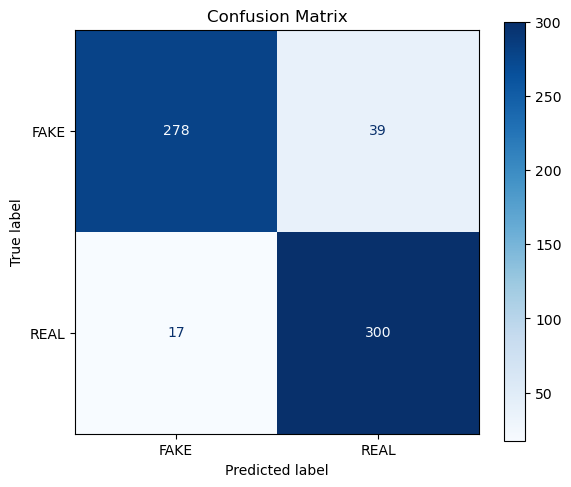

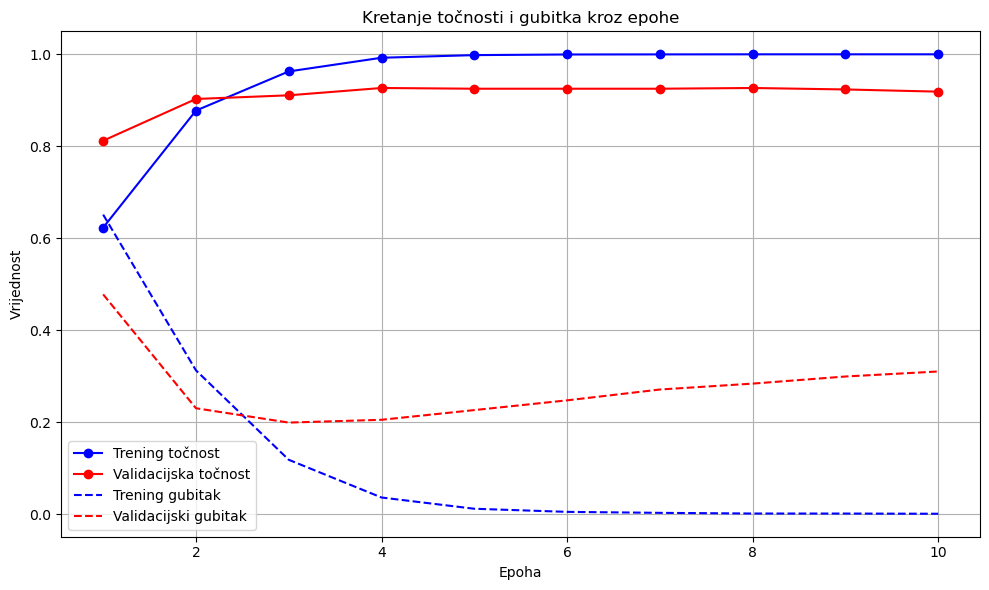

In [53]:
myNews(model_1)
plot_confusion(model_1, X_test_pad, y_test)
plotMetrics(history_1)

# Model 2

In [32]:
# Second, improved CNN model
EMBEDDING_DIM_2 = 150  # Embedding-vector size: 150 dimensions instead of 100

# 1) The input layer receives sequences of length MAXLEN tokens
input_2 = Input(shape=(MAXLEN,))

# 2) Embedding layer:
#    - maps each token (word index) to a 150-dimensional vector
#    - the embedding-matrix weights are trainable, so semantic learning occurs during training
#  SpatialDropout1D(0.25):
#    - randomly disables 25% of embedding dimensions
#    - increases robustness so the model does not depend too strongly on one dimension
embed_2 = Embedding(
    input_dim=MAX_VOCAB_SIZE, 
    output_dim=EMBEDDING_DIM_2,
    trainable=True
)(input_2)
drop_2 = SpatialDropout1D(0.25)(embed_2)

# 3) Multi-channel convolutional filters (kernel_size = 3, 5, and 7):
#    - Conv1D: learn 128 different filters that detect local patterns
#    - kernel_size=k: filter width (how many words are analyzed at once)
#    - activation="relu": introduces nonlinearity and sets negative values to 0
#    - padding="same": output length remains equal to input length
#    - BatchNormalization: normalizes activations before pooling, accelerating and stabilizing learning
#    - GlobalMaxPooling1D: pools each feature map along the temporal axis, keeping the strongest activation
def conv_branch(x, k):
    c = Conv1D(
        filters=128,
        kernel_size=k,
        activation="relu",
        padding="same"
    )(x)
    c = BatchNormalization()(c)
    return GlobalMaxPooling1D()(c)

# Apply three paths with different kernel widths
p3_2 = conv_branch(drop_2, 3)  # 3-gram convolution -> recognizes trigrams
p5_2 = conv_branch(drop_2, 5)  # 5-gram convolution -> recognizes five-gram phrases
p7_2 = conv_branch(drop_2, 7)  # 7-gram convolution -> recognizes longer word sequences

# 4) Concatenate merges all pooled features from the three paths into one vector
merged_2 = Concatenate()([p3_2, p5_2, p7_2])

# 5) Additional fully connected layers (Dense) with Dropout regularization:
#    - first Dense(128, relu): learns nonlinear relationships among the merged features
#    - Dropout(0.5): disables 50% of neurons, preventing overfitting
#    - second Dense(64, relu): deeper abstraction, learns more sophisticated combinations
#    - new Dropout(0.5): further strengthens regularization before the output
x2 = Dense(128, activation="relu")(merged_2)
x2 = Dropout(0.5)(x2)
x2 = Dense(64, activation="relu")(x2)
x2 = Dropout(0.5)(x2)

# 6) Output layer for binary classification:
#    - Dense(1, sigmoid): returns P(REAL) in the range [0,1]
output_2 = Dense(1, activation="sigmoid")(x2)

# 7) Model creation and compilation:
#    - loss="binary_crossentropy": binary cross-entropy for two classes
#    - optimizer=Adam(learning_rate=0.001): Adam optimizer with initial learning rate 0.001
#    - metrics=["accuracy"]: track accuracy during training/validation
model_2 = Model(inputs=input_2, outputs=output_2)
model_2.compile(
    loss="binary_crossentropy",
    optimizer=Adam(learning_rate=0.001),
    metrics=["accuracy"]
)

# 8) Callbacks for controlling the training process:
early_stop_2 = EarlyStopping(
    monitor="val_loss",          # monitor the loss value on validation data
    patience=3,                  # allow up to 3 epochs without val_loss improvement before stopping
    verbose=1,                   # print a message when training stops
    mode="min",                  # seek the minimum val_loss value (lower is better)
    restore_best_weights=True    # after stopping, restore weights from the epoch with the best val_loss
)

# Reduce Learning Rate On Plateau
reduce_lr_2 = ReduceLROnPlateau(
    monitor="val_loss",          # monitor the same signal: validation loss
    factor=0.5,                  # reduction factor: new_lr = old_lr * factor
    patience=1,                  # wait 1 epoch without improvement before reducing the rate
    verbose=1,                   # print information whenever lr is reduced
    mode="min",                  # expect val_loss to decrease
    min_delta=1e-4,              # changes smaller than this threshold do not count as improvement
    cooldown=0,                  # number of cooldown epochs immediately after reduction before monitoring again
    min_lr=1e-6                  # lowest allowed learning-rate value
)


# 9) Model training:
#    - batch_size=64: update weights after every 64 examples
#    - epochs=15: at most 15 epochs (may be interrupted by early stopping)
#    - validation_data: validation set for monitoring val_loss and val_accuracy
#    - shuffle=True: shuffle data before each epoch
history_2 = model_2.fit(
    X_train_pad,
    y_train,
    batch_size=64,
    epochs=15,
    validation_data=(X_val_pad, y_val),
    shuffle=True,
    callbacks=[early_stop_2, reduce_lr_2],
    verbose=1
)

# 10) Evaluation on the test set and result printing:
test_loss_2, test_acc_2 = model_2.evaluate(X_test_pad, y_test)
print("Test accuracy_2 =", test_acc_2)


Epoch 1/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 10s 115ms/step - accuracy: 0.5014 - loss: 0.9695 - val_accuracy: 0.5637 - val_loss: 0.6922 - learning_rate: 0.0010
Epoch 2/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 9s 116ms/step - accuracy: 0.6206 - loss: 0.6224 - val_accuracy: 0.8726 - val_loss: 0.6229 - learning_rate: 0.0010
Epoch 3/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 10s 127ms/step - accuracy: 0.8475 - loss: 0.3288 - val_accuracy: 0.8869 - val_loss: 0.5006 - learning_rate: 0.0010
Epoch 4/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 9s 108ms/step - accuracy: 0.9426 - loss: 0.1397 - val_accuracy: 0.8933 - val_loss: 0.3688 - learning_rate: 0.0010
Epoch 5/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 10s 123ms/step - accuracy: 0.9781 - loss: 0.0624 - val_accuracy: 0.9124 - val_loss: 0.2411 - learning_rate: 0.0010
Epoch 6/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 9s 108ms/step - accuracy: 0.9853 - loss: 0.0369 - val_accuracy: 0.9188 - val_loss: 0.2124 - learning_rate: 0.0010
Epoch 7/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 9s 118ms/step - accuracy: 0.9876 - loss: 0.0288

index_fake
Probability of REAL: 0.8694
Predicted label:     REAL
--------------------------------------------------
energy_real
Probability of REAL: 0.5686
Predicted label:     REAL
--------------------------------------------------
darkMatter_fake
Probability of REAL: 0.0437
Predicted label:     FAKE
--------------------------------------------------
nasa_real
Probability of REAL: 0.3025
Predicted label:     FAKE
--------------------------------------------------
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


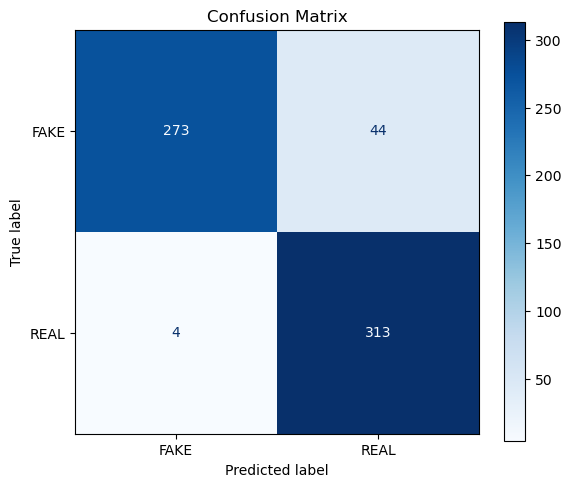

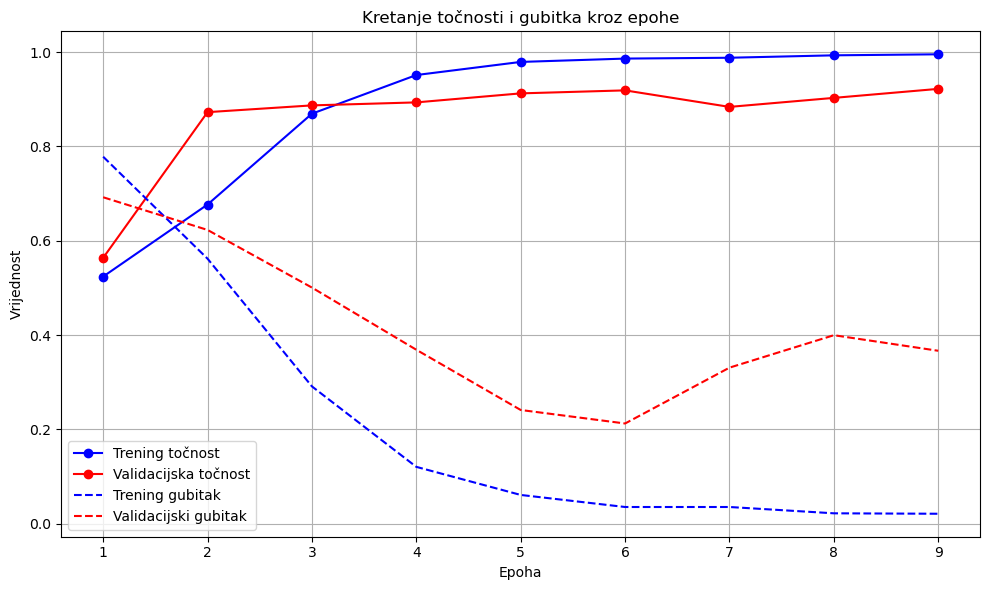

In [50]:
myNews(model_2)
plot_confusion(model_2, X_test_pad, y_test)
plotMetrics(history_2)

# Model 3

In [45]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input,                 # defines the input layer (placeholder for data)
    Embedding,             # learns dense word vectors
    SpatialDropout1D,      # regularizes entire embedding channels
    Conv1D,                # 1D convolutional layer for local text patterns
    GlobalMaxPooling1D,    # aggregates the temporal dimension of Conv1D output into one value
    Concatenate,           # combines multiple tensor paths into one
    Dense,                 # fully connected layer (classification or hidden layer)
    Dropout,               # randomly disables neurons for regularization
    BatchNormalization     # normalizes activations to stabilize training
)
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.sequence import pad_sequences

# 1) Pad sequences again so all have the same MAXLEN length
#    - X_train_seq, X_val_seq, X_test_seq: lists of integer sequences for each sample
#    - pad_sequences returns a NumPy array with dimensions (num_examples, MAXLEN)
#    - padding="post": adds zeros AT THE END of the sequence if it is shorter than MAXLEN
#    - truncating="post": truncates words at the end if the sequence is longer than MAXLEN
X_train_pad3 = pad_sequences(X_train_seq, maxlen=MAXLEN, padding="post", truncating="post")
X_val_pad3   = pad_sequences(X_val_seq,   maxlen=MAXLEN, padding="post", truncating="post")
X_test_pad3  = pad_sequences(X_test_seq,  maxlen=MAXLEN, padding="post", truncating="post")

# 2) Define hyperparameters for model 3
EMBEDDING_DIM_3 = 150   # embedding-vector dimension for each word
L2_REG          = 1e-3  # L2 regularization coefficient (stronger weight penalty)
DROP_RATE       = 0.6   # dropout rate in Dropout layers

# 3) Build the functional model
inp_3 = Input(shape=(MAXLEN,))  
#       ^ input layer expects a 2D tensor: (batch_size, MAXLEN)

# 3a) Embedding layer
x_3 = Embedding(
    input_dim=MAX_VOCAB_SIZE,  # vocabulary size (maximum index + 1)
    output_dim=EMBEDDING_DIM_3,# embedded-vector dimension for each token
    trainable=True            # the weight matrix is learned during training
)(inp_3)
#     ^ output is a tensor of shape (batch_size, MAXLEN, EMBEDDING_DIM_3)

# 3b) SpatialDropout1D
x_3 = SpatialDropout1D(DROP_RATE)(x_3)
#       ^ with probability DROP_RATE, completely disables entire dimensions
#         of the embedding channel (e.g., one of 150 dimensions) for each sample

# 3c) Define a function for a parallel convolutional branch
def conv_branch_3(x, k):
    """
    Creates one convolutional path:
      - Conv1D with fewer filters for faster training
      - BatchNormalization to stabilize the activation distribution
      - GlobalMaxPooling1D to reduce the temporal dimension
    """
    c = Conv1D(
        filters=32,              # number of kernels (feature maps) in this branch
        kernel_size=k,           # window width (n-gram length)
        activation="relu",       # ReLU activation: max(0, x)
        padding="same",          # output width = input width (MAXLEN)
        kernel_regularizer=l2(L2_REG)  # L2 regularization of kernel weights
    )(x)
    #   ^ shape after Conv1D: (batch_size, MAXLEN, 32)
    c = BatchNormalization()(c)
    #   ^ normalizes activations by batch: accelerates and stabilizes training
    return GlobalMaxPooling1D()(c)
    #   ^ returns (batch_size, 32): takes the maximum activation of each kernel

# 3d) Create three parallel branches with kernel_size = 3, 5, and 7
b3_3 = conv_branch_3(x_3, 3)   # 3-gram analysis
b5_3 = conv_branch_3(x_3, 5)   # 5-gram analysis
b7_3 = conv_branch_3(x_3, 7)   # 7-gram analysis

# 3e) Concatenate the outputs of all three branches
merged_3 = Concatenate()([b3_3, b5_3, b7_3])
#           ^ shape: (batch_size, 32+32+32 = 96)

# 3f) Dense layer for combining features
h_3 = Dense(
    units=64,                  # number of neurons in the hidden layer
    activation="relu",         # ReLU activation for nonlinearity
    kernel_regularizer=l2(L2_REG)  # L2 penalty on weights
)(merged_3)
#     ^ shape: (batch_size, 64)
h_3 = BatchNormalization()(h_3)
#     ^ normalizes Dense-layer outputs
h_3 = Dropout(DROP_RATE)(h_3)
#     ^ with probability DROP_RATE, disables half of the neurons

# 3g) Output layer with sigmoid activation for binary classification
out_3 = Dense(
    units=1,                   # one output: P(REAL)
    activation="sigmoid"       # compression to [0,1]
)(h_3)
#     ^ shape: (batch_size, 1)

# 3h) Create the Model object
model_3 = Model(inputs=inp_3, outputs=out_3)

# 3i) Compile the model
model_3.compile(
    loss="binary_crossentropy",       # binary cross-entropy
    optimizer=Adam(learning_rate=0.001), # Adam optimizer with initial LR=0.001
    metrics=["accuracy"]              # metrics to track during training
)

# 4) Callbacks for controlling training
es3 = EarlyStopping(
    monitor="val_loss",        # monitor validation loss
    patience=1,                # allow 1 epoch without improvement
    restore_best_weights=True  # after stopping, restore the best model weights
)
rlrp3 = ReduceLROnPlateau(
    monitor="val_loss",   # monitor validation loss
    factor=0.5,           # halve the learning rate when it stagnates
    patience=1,           # after 1 epoch without improvement
    min_lr=1e-6           # do not go below this limit
)

# 5) Model training
history3 = model_3.fit(
    X_train_pad3, y_train,               # training data and labels
    validation_data=(X_val_pad3, y_val), # validation set
    epochs=8,                            # train for up to 8 epochs
    batch_size=64,                       # mini-batch size
    shuffle=True,                        # shuffle input data each epoch
    callbacks=[es3, rlrp3],              # activate the defined callbacks
    verbose=1                            # print progress in the console
)

# 6) Evaluation on the test set
loss3, acc3 = model_3.evaluate(X_test_pad3, y_test)
print("Model 3 test accuracy:", acc3)


Epoch 1/8
80/80 ━━━━━━━━━━━━━━━━━━━━ 7s 76ms/step - accuracy: 0.5354 - loss: 1.0442 - val_accuracy: 0.5000 - val_loss: 0.9151 - learning_rate: 0.0010
Epoch 2/8
80/80 ━━━━━━━━━━━━━━━━━━━━ 6s 69ms/step - accuracy: 0.7422 - loss: 0.7245 - val_accuracy: 0.5000 - val_loss: 0.8631 - learning_rate: 0.0010
Epoch 3/8
80/80 ━━━━━━━━━━━━━━━━━━━━ 6s 69ms/step - accuracy: 0.8533 - loss: 0.5488 - val_accuracy: 0.5525 - val_loss: 0.7941 - learning_rate: 0.0010
Epoch 4/8
80/80 ━━━━━━━━━━━━━━━━━━━━ 6s 71ms/step - accuracy: 0.8994 - loss: 0.4390 - val_accuracy: 0.7946 - val_loss: 0.6490 - learning_rate: 0.0010
Epoch 5/8
80/80 ━━━━━━━━━━━━━━━━━━━━ 6s 70ms/step - accuracy: 0.9544 - loss: 0.3371 - val_accuracy: 0.8806 - val_loss: 0.5195 - learning_rate: 0.0010
Epoch 6/8
80/80 ━━━━━━━━━━━━━━━━━━━━ 6s 72ms/step - accuracy: 0.9689 - loss: 0.2869 - val_accuracy: 0.8838 - val_loss: 0.4765 - learning_rate: 0.0010
Epoch 7/8
80/80 ━━━━━━━━━━━━━━━━━━━━ 5s 68ms/step - accuracy: 0.9793 - loss: 0.2494 - val_accuracy: 

index_fake
Probability of REAL: 0.2071
Predicted label:     FAKE
--------------------------------------------------
energy_real
Probability of REAL: 0.5696
Predicted label:     REAL
--------------------------------------------------
darkMatter_fake
Probability of REAL: 0.0226
Predicted label:     FAKE
--------------------------------------------------
nasa_real
Probability of REAL: 0.0526
Predicted label:     FAKE
--------------------------------------------------
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


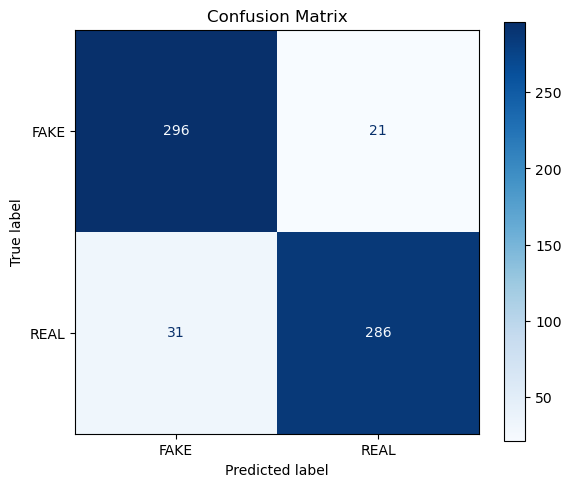

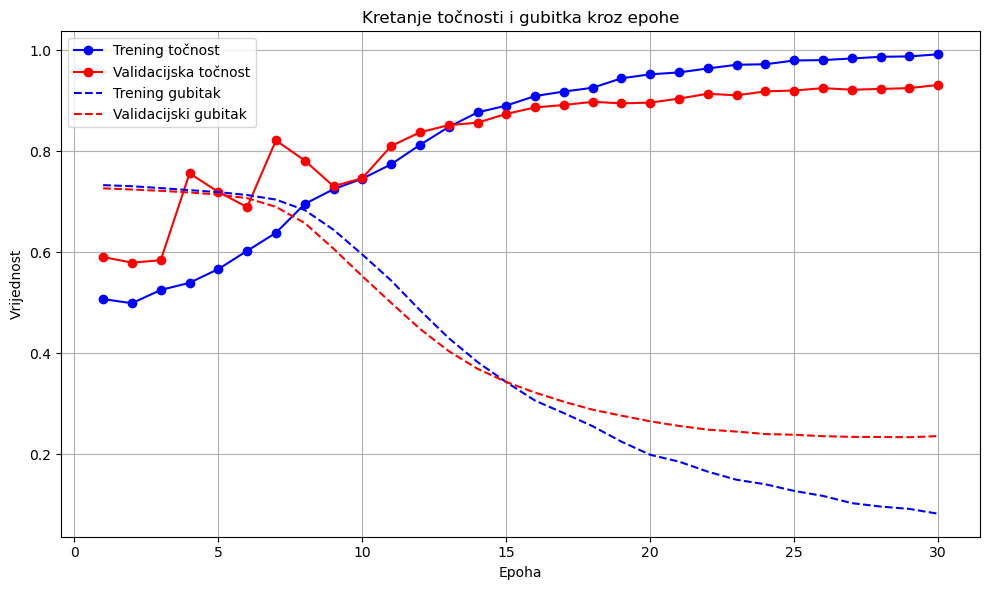

In [48]:
myNews(model_3)
plot_confusion(model_3, X_test_pad, y_test)
plotMetrics(history_3)